# Olympic Country Efficiency Model

## 1) Load Data
Using Our Dataset we created in make_new_csv.py we created a country olympic dataset that also includes gdp and population. Lets load that into a dataframe 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from xgboost import XGBRegressor

#Load in dataset
df = pd.read_csv("olympics_country_year_features.csv")

#Clean some of the na values
df_clean = df.dropna(subset=["gdp_per_capita", "population", "total_medals"]).copy()

#Features we want to drop
features_to_drop = [
    "NOC", "ISO3", "Year", "income_group",
    "Gold", "Silver", "Bronze",
    "total_medals", "medals_per_athlete"
]

X_unclean = df.drop(columns=features_to_drop)
y_unclean = df["total_medals"]

X = df_clean.drop(columns=features_to_drop)
y = df_clean["total_medals"]

print(f"Training on {len(df_clean)} records with {X.shape[1]} features.\n")


Training on 1175 country-year records with 9 features.



## Visualization
Lets create a few graphs/visualizations of our data.

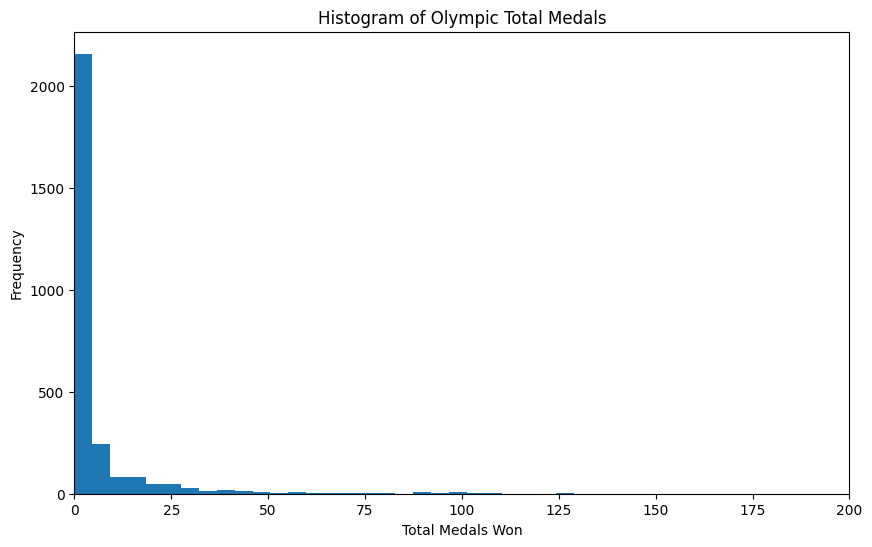

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(y_unclean, bins=50)

plt.title("Histogram of Olympic Total Medals")
plt.xlabel("Total Medals Won")
plt.ylabel("Frequency")
plt.xlim(0, 200) 
plt.show()

 Here we see that the data is very imbalanced. Meaning there are way more countries in the 0-10 medal range vs any other range. This will make model creation a little tricky. 
Lets see how each variable stacks up against total medals

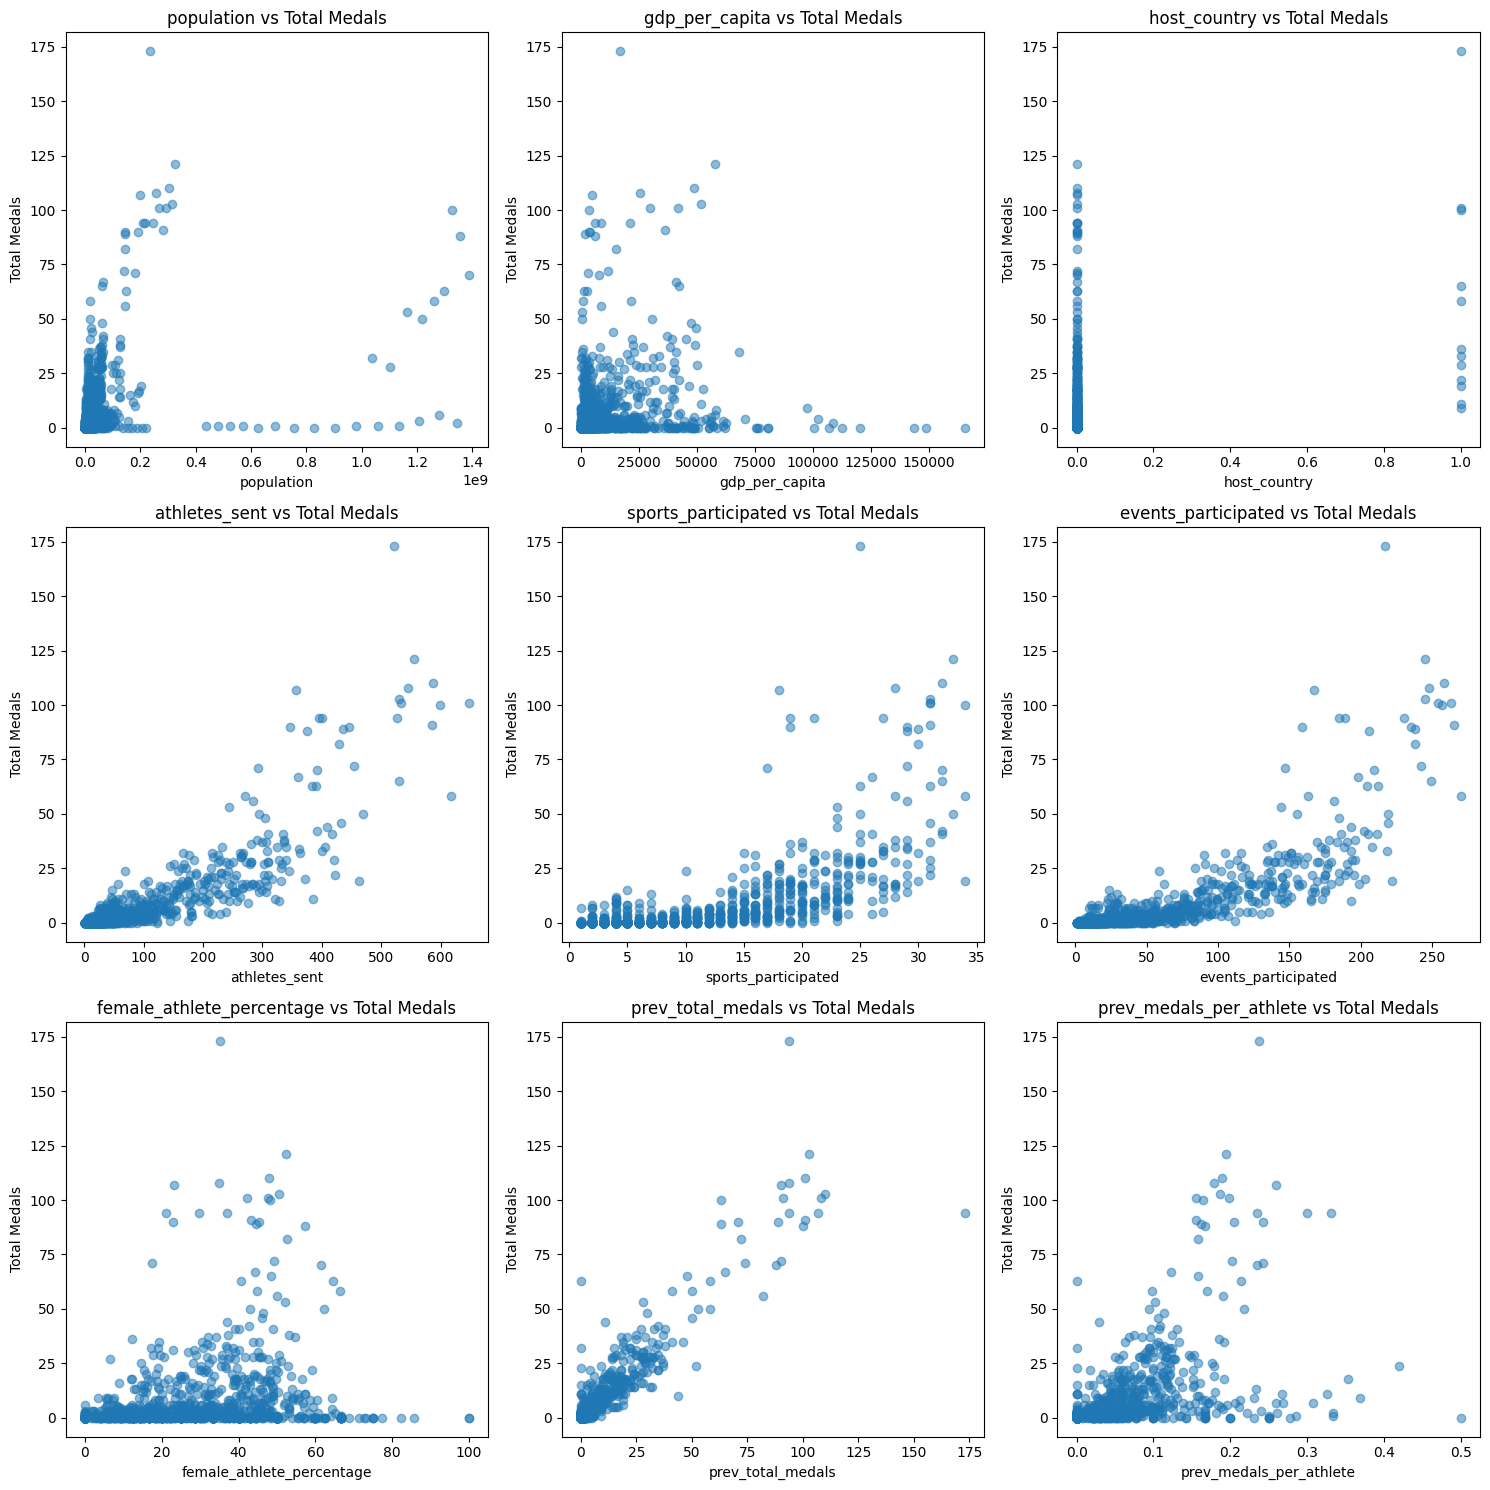

In [ ]:
# Features to visualize against medals
features = [col for col in X.columns]

# Grid size
ncols = 3
nrows = (len(features) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df_clean[feature], y, alpha=0.5)
    axes[i].set_title(f"{feature} vs Total Medals")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Total Medals")

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

 The Biggest Variables that seem to have high correlation are Athletes Sent, Previous Total Medals, Events Participated. The other ones may have a little correlation but its not too obvious

## 2) Train/Compare Models

In [13]:

kf = KFold (n_splits=5,shuffle=True,random_state=42)

# Different models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100,learning_rate=0.1,random_state=42)
}

results = {}

#Evaluate model
print("=== Model Performance (R²) ===\n")

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    results[name] = scores

    print(f"{name}:")
    print(f" Scores: {np.round(scores,4)}")
    print(f" Avg R²: {np.mean(scores):.4f}\n")


#Fit Best Model
rf_model = models["Random Forest"]
rf_model.fit(X,y)

=== Model Performance (R²) ===

Linear Regression:
 Scores: [0.8471 0.8729 0.8804 0.928  0.9379]
 Avg R²: 0.8933



Random Forest:
 Scores: [0.8668 0.9077 0.9081 0.9155 0.9316]
 Avg R²: 0.9059

XGBoost:
 Scores: [0.8674 0.9104 0.9271 0.8876 0.9138]
 Avg R²: 0.9013



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## 3) Find Feature Importance

=== Feature Importances (Random Forest) ===
prev_total_medals            0.728790
athletes_sent                0.149300
events_participated          0.064925
population                   0.013798
prev_medals_per_athlete      0.012004
female_athlete_percentage    0.009003
gdp_per_capita               0.008278
host_country                 0.007813
sports_participated          0.006088
dtype: float64 



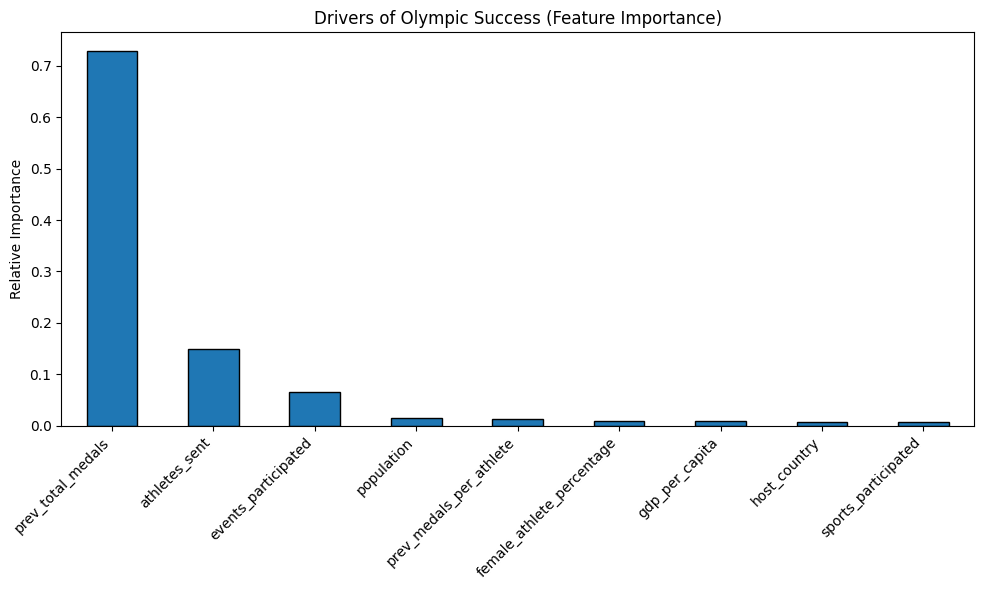

=== Final Model Comparison ===
Linear Regression: 0.8933
Random Forest: 0.9059
XGBoost: 0.9013


In [ ]:
#Find Feature Importance
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importances = importances.sort_values(
    ascending=False
)

print("=== Feature Importances (Random Forest) ===")
print(importances, "\n")


#Plotting Importance
plt.figure(figsize=(10,6))
importances.plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Drivers of Olympic Success (Feature Importance)")
plt.ylabel("Relative Importance")
plt.xticks(
    rotation=45,
    ha="right"
)
plt.tight_layout()
plt.show()


print("Feature Importance: ")

for name in results:
    print(
        f"{name}: {np.mean(results[name]):.4f}"
    )

Comparing each feature, we see that prev_total_medals and athletes_sent are far more important than any other feature making all the other variables nearly useless. Lets do the model again but only use prev_total_medals and athletes_Sent

In [ ]:
features = [
    "prev_total_medals",
    "athletes_sent"
]

# could use df unclean, since were not using variables that have missing variables
X_two = df_clean[features]
y_two = df_clean["total_medals"]

print("Using features:", features)
print()

#Cross Validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Random Forest Model
rf_main_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

scores = cross_val_score(
    rf_main_model,
    X_two,
    y_two,
    cv=kf,
    scoring="r2"
)

print("=== Random Forest Performance ===")
print("Scores:", np.round(scores,4))
print("Avg R²:", np.mean(scores))


rf_main_model.fit(X_two, y_two)

Using features: ['prev_total_medals', 'athletes_sent']

=== Random Forest Performance ===
Scores: [0.8602 0.8865 0.9044 0.9393 0.9097]
Avg R²: 0.9000167818144259


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Lets save this model using pickle. This will be our prediction model. 

In [ ]:
import pickle

with open("App/rf_main_model.pkl", "wb") as f:
    pickle.dump(rf_main_model, f)

features = ["prev_total_medals","athletes_sent"]

with open("App/features_main_model.pkl", "wb") as f:
    pickle.dump(features, f)



### We now have the model that can predict total medals. But now lets try to track country efficiency. 

# Create Efficiency Model

## Import and Merge HDI Dataset

In [ ]:
#load in human devlopment index cav
hdi = pd.read_csv("Datasets/hdi.csv")  # change filename if needed

# 2. Convert wide hdi columns into long format (similar to how the gdp and population datasets are)
hdi_cols = [col for col in hdi.columns if col.startswith("Human Development Index")]

hdi_long = hdi.melt(
    id_vars=["ISO3", "Country"],
    value_vars=hdi_cols,
    var_name="Year",
    value_name="hdi"
)


hdi_long["Year"] = hdi_long["Year"].str.extract(r"(\d{4})").astype(int)

df_hdi = df_clean.merge(
    hdi_long[["ISO3", "Year", "hdi"]],
    on=["ISO3", "Year"],
    how="left"
)
#handle n/a values
df_hdi = df_hdi.dropna(
    subset=["gdp_per_capita", "population", "hdi", "total_medals"]
).copy()


simple_features = [
    "gdp_per_capita",
    "population",
    "hdi"
]

X_simple = df_hdi[simple_features]
y_simple = df_hdi["total_medals"]

print(f"Using features: {simple_features}")
print(f"Dataset size: {len(X_simple)}")

Using features: ['gdp_per_capita', 'population', 'hdi']
Dataset size: 714


In [ ]:
from sklearn.preprocessing import MinMaxScaler

#normalize using minmaxscaler(
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_simple)


simple_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

simple_results = {}

print("=== GDP + Population + HDI Model (Normalized) ===\n")

for name, model in simple_models.items():
    scores = cross_val_score(model, X_norm, y_simple, cv=kf, scoring="r2")
    simple_results[name] = scores

    print(f"{name}:")
    print(f"  Scores: {np.round(scores, 4)}")
    print(f"  Avg R²: {np.mean(scores):.4f}\n")

=== GDP + Population + HDI Model (Normalized) ===

Linear Regression:
  Scores: [0.3314 0.2286 0.2168 0.3117 0.2608]
  Avg R²: 0.2699

Random Forest:
  Scores: [0.7122 0.775  0.8454 0.7553 0.677 ]
  Avg R²: 0.7530

XGBoost:
  Scores: [0.6897 0.8276 0.7569 0.7244 0.5733]
  Avg R²: 0.7144



## Test Feature Performance on efficiency model

Feature Importances: 
population        0.604655
hdi               0.267896
gdp_per_capita    0.127449
dtype: float64


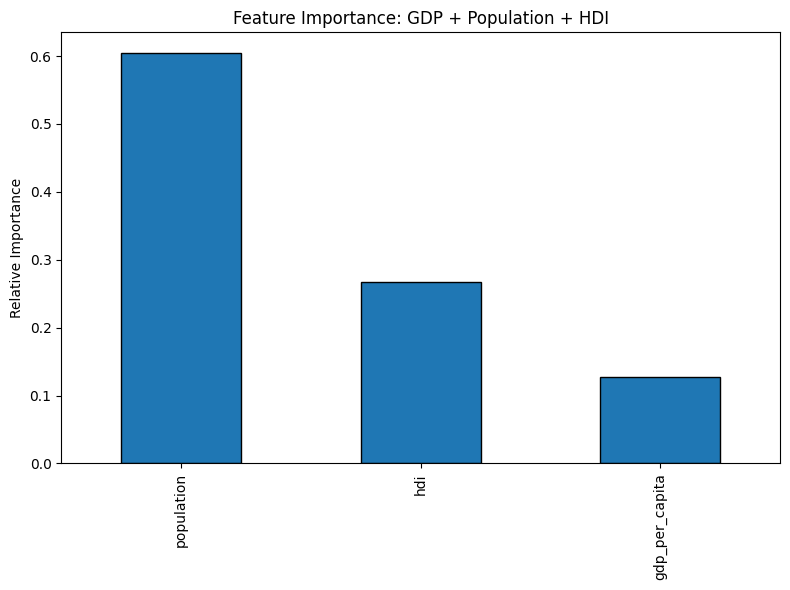

In [23]:
# Fit Random Forest on GDP + Population + HDI
rf_efficiency_model = RandomForestRegressor(n_estimators=100,random_state=42)

rf_efficiency_model.fit(X_simple, y_simple)


#Feature Importances
importances = pd.Series(
    rf_efficiency_model.feature_importances_,
    index=X_simple.columns
).sort_values(ascending=False)

print("Feature Importances: ")
print(importances)


#Plot
plt.figure(figsize=(8,6))

importances.plot(kind="bar",edgecolor="black")

plt.title("Feature Importance: GDP + Population + HDI")
plt.ylabel("Relative Importance")

plt.tight_layout()
plt.show()

Save the model using pickle

In [24]:
import pickle

with open("App/rf_efficiency_model.pkl", "wb") as f:
    pickle.dump(rf_efficiency_model, f)

features_efficiency = [
    "gdp_per_capita",
    "population",
    "hdi"
]

with open("App/features_efficiency_model.pkl", "wb") as f:
    pickle.dump(features_efficiency, f)

While using the model may be less accurate than our first model, this gives a much more interesting model that can predict how many medals a country can win based off of their population, hdi, and gdp per capita.

## Lets Try Some Examples

In [ ]:


# Use Random Forest and XGB
rf = RandomForestRegressor(n_estimators=100,random_state=42)
xgb = XGBRegressor(n_estimators=100,learning_rate=0.1,random_state=42)
rf.fit(X_simple, y_simple)
xgb.fit(X_simple, y_simple)


# Example countries, along with their population, gdp per capita, and human development index
examples = pd.DataFrame({
    "gdp_per_capita":[
        80000,   # USA
        50000,   # Germany
        15000,   # Brazil
        12000,   # India
        6500     # Jamaica
    ],

    "population":[
        330e6,
        84e6,
        215e6,
        1400e6,
        3e6
    ],

    "hdi":[
        0.92,   # USA-ish
        0.94,   # Germany-ish
        0.76,   # Brazil-ish
        0.64,   # India-ish
        0.73    # Jamaica-ish
    ]

},
index=[
    "United States",
    "Germany",
    "Brazil",
    "India",
    "Jamaica"
])


# Use only model features
pred_input = examples[
    ["gdp_per_capita",
     "population",
     "hdi"]
]

examples["RF Pred"] = rf.predict(pred_input)
examples["XGB Pred"] = xgb.predict(pred_input)

print(examples)

               gdp_per_capita    population   hdi  RF Pred    XGB Pred
United States           80000  3.300000e+08  0.92   115.29  117.974945
Germany                 50000  8.400000e+07  0.94    54.60   59.746002
Brazil                  15000  2.150000e+08  0.76    32.12   36.817844
India                   12000  1.400000e+09  0.64    40.87   14.445778
Jamaica                  6500  3.000000e+06  0.73     1.60    1.677037


We can now compare these numbers to how they actually perform in recent years to see how efficiently they compete. 

## Lets Try a Neural Network

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
import numpy as np



nn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=42
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

nn_scores = cross_val_score(
    nn_model,
    X_simple,
    y_simple,
    cv=kf,
    scoring="r2"
)

print("=== Neural Network Performance (GDP + Population + HDI) ===")
print(f"Scores: {np.round(nn_scores, 4)}")
print(f"Avg R²: {np.mean(nn_scores):.4f}")

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


=== Neural Network Performance (GDP + Population + HDI) ===
Scores: [0.5988 0.6523 0.7273 0.7355 0.6211]
Avg R²: 0.6670


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
